In [ ]:
!pip install -q optuna shap xgboost scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.0 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import sys
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna

import xgboost as xgb

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import StandardScaler, OneHotEncoder
from sklearn.compose          import ColumnTransformer
from sklearn.ensemble         import RandomForestClassifier
from sklearn.svm              import SVC
from sklearn.metrics          import (
    accuracy_score, recall_score, precision_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
)

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
RANDOM_STATE    = 42
DATA_PATH       = "dataset/heart_statlog_cleveland_hungary_final.csv"
TARGET          = "target"
TEST_SIZE       = 0.20
CV_FOLDS        = 5
N_OPTUNA_TRIALS = 80
FIG_DPI         = 130

np.random.seed(RANDOM_STATE)

plt.rcParams.update({
    "figure.dpi"       : FIG_DPI,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "DejaVu Sans",
})

PALETTE = {
    "xgb" : "#E8724C",
    "rf"  : "#4C9BE8",
    "svm" : "#2CA02C",
}

print("=" * 70)
print("  HEART DISEASE CLASSIFICATION — XGBoost vs RF vs SVM")
print("=" * 70)

  HEART DISEASE CLASSIFICATION — XGBoost vs RF vs SVM


In [ ]:
def maybe_upload(path: str) -> None:
    if os.path.exists(path):
        print(f"[✓] Dataset found: {path}")
        return
    try:
        from google.colab import files as colab_files  # type: ignore
        print("[!] Dataset missing — please upload 'heart_statlog_cleveland_hungary_final.csv'")
        uploaded = colab_files.upload()
        os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
        os.rename(list(uploaded.keys())[0], path)
        print(f"[✓] Saved to: {path}")
    except ImportError:
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. "
            "Place the CSV inside a 'dataset/' folder."
        )

maybe_upload(DATA_PATH)

[✓] Dataset found: dataset/heart_statlog_cleveland_hungary_final.csv


In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"\n[1/8] Dataset: {df.shape[0]} rows × {df.shape[1]} cols | missing={df.isnull().sum().sum()}")
print(f"      Target: {dict(df[TARGET].value_counts())}\n")

CATEGORICAL_FEATURES = ["sex", "chest pain type", "fasting blood sugar",
                         "resting ecg", "exercise angina", "ST slope"]
NUMERICAL_FEATURES   = ["age", "resting bp s", "cholesterol",
                         "max heart rate", "oldpeak"]

X_raw = df.drop(columns=[TARGET])
y     = df[TARGET]


[1/8] Dataset: 1190 rows × 12 cols | missing=0
      Target: {1: np.int64(629), 0: np.int64(561)}



In [ ]:
print("[2/8] Splitting 80/20 stratified")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)
print(f"      Train: {X_train_raw.shape[0]} | Test: {X_test_raw.shape[0]}\n")

[2/8] Splitting 80/20 stratified
      Train: 952 | Test: 238



In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(),                                  NUMERICAL_FEATURES),
        ("cat", OneHotEncoder(drop="first", sparse_output=False),  CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)
X_train_proc = preprocessor.fit_transform(X_train_raw)
X_test_proc  = preprocessor.transform(X_test_raw)

cat_names    = preprocessor.named_transformers_["cat"] \
                            .get_feature_names_out(CATEGORICAL_FEATURES).tolist()
FEATURE_NAMES = NUMERICAL_FEATURES + cat_names
print(f"[✓] Preprocessed features: {len(FEATURE_NAMES)}\n")

[✓] Preprocessed features: 16



In [ ]:
print("[3/8] Training Random Forest (baseline)")
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=15, min_samples_split=2,
    min_samples_leaf=1, max_features="sqrt", bootstrap=True,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
)
rf_model.fit(X_train_raw, y_train)
print("      [✓] Random Forest trained.\n")

[3/8] Training Random Forest (baseline)
      [✓] Random Forest trained.



In [ ]:
def objective(trial):
    params = {
        "objective"       : "binary:logistic",
        "eval_metric"     : "logloss",
        "random_state"    : RANDOM_STATE,
        "n_estimators"    : trial.suggest_int  ("n_estimators",    50,  500),
        "max_depth"       : trial.suggest_int  ("max_depth",        3,   10),
        "learning_rate"   : trial.suggest_float("learning_rate",  0.01, 0.3,  log=True),
        "subsample"       : trial.suggest_float("subsample",       0.5,  1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.5,  1.0),
        "min_child_weight": trial.suggest_int  ("min_child_weight", 1,   10),
        "gamma"           : trial.suggest_float("gamma",            0,    5),
        "reg_alpha"       : trial.suggest_float("reg_alpha",        0,    1),
        "reg_lambda"      : trial.suggest_float("reg_lambda",       0.5,  5),
    }
    model  = xgb.XGBClassifier(**params)
    skf    = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train_proc, y_train,
                             cv=skf, scoring="roc_auc", n_jobs=-1)
    return scores.mean()

print(f"[4/8] Optuna HPO (XGBoost) — {N_OPTUNA_TRIALS} trials")
study = optuna.create_study(
    direction="maximize", study_name="xgboost_heart_hpo",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

best_params = study.best_params
best_params.update({"objective": "binary:logistic", "eval_metric": "logloss",
                     "random_state": RANDOM_STATE})
print(f"\n      [✓] Best CV AUC-ROC: {study.best_value:.4f}")
print(f"      Best params: {best_params}\n")

[4/8] Optuna HPO (XGBoost) — 80 trials


  0%|          | 0/80 [00:00<?, ?it/s]


      [✓] Best CV AUC-ROC: 0.9504
      Best params: {'n_estimators': 356, 'max_depth': 7, 'learning_rate': 0.127397824177842, 'subsample': 0.6148985575257964, 'colsample_bytree': 0.6639400789323814, 'min_child_weight': 1, 'gamma': 0.022904229688582595, 'reg_alpha': 0.7268865388800891, 'reg_lambda': 4.46727253981053, 'objective': 'binary:logistic', 'eval_metric': 'logloss', 'random_state': 42}



In [ ]:
print("[5/8] Training final XGBoost on full training set")
xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(X_train_proc, y_train)
print("      [✓] XGBoost trained.\n")

[5/8] Training final XGBoost on full training set
      [✓] XGBoost trained.



In [ ]:
print("[6/8] Training SVM (RBF kernel, probability=True)")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale',
                probability=True, random_state=RANDOM_STATE)
svm_model.fit(X_train_proc, y_train)
print("      [✓] SVM trained.\n")

[6/8] Training SVM (RBF kernel, probability=True)
      [✓] SVM trained.



In [ ]:
def compute_metrics(y_true, y_pred, y_prob, label):
    return {
        "Model"    : label,
        "Accuracy" : round(accuracy_score (y_true, y_pred),       4),
        "Recall*"  : round(recall_score   (y_true, y_pred),       4),
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score" : round(f1_score       (y_true, y_pred),       4),
        "AUC-ROC"  : round(roc_auc_score  (y_true, y_prob),       4),
    }

print("[7/8] Evaluating models")

y_pred_xgb  = xgb_model.predict(X_test_proc)
y_prob_xgb  = xgb_model.predict_proba(X_test_proc)[:, 1]

y_pred_rf   = rf_model.predict(X_test_raw)
y_prob_rf   = rf_model.predict_proba(X_test_raw)[:, 1]

y_pred_svm  = svm_model.predict(X_test_proc)
y_prob_svm  = svm_model.predict_proba(X_test_proc)[:, 1]

metrics_xgb = compute_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost (Optuna-Optimised)")
metrics_rf  = compute_metrics(y_test, y_pred_rf,  y_prob_rf,  "Random Forest (Baseline)")
metrics_svm = compute_metrics(y_test, y_pred_svm, y_prob_svm, "SVM (RBF kernel)")

results_df = pd.DataFrame([metrics_xgb, metrics_rf, metrics_svm]).set_index("Model")

print("\n" + "=" * 70)
print("  MODEL COMPARISON TABLE")
print("  (* Recall is the most critical metric for medical screening)")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

for label, y_pred in [("XGBoost (Optuna-Optimised)", y_pred_xgb),
                       ("Random Forest (Baseline)",   y_pred_rf),
                       ("SVM (RBF kernel)",           y_pred_svm)]:
    print(f"\n── {label} ──")
    print(classification_report(y_test, y_pred,
                                 target_names=["No Disease (0)", "Heart Disease (1)"]))

winner_name = results_df["AUC-ROC"].idxmax()
print(f"\n★  Winner (highest AUC-ROC): {winner_name}\n")

[7/8] Evaluating models

  MODEL COMPARISON TABLE
  (* Recall is the most critical metric for medical screening)
                            Accuracy  Recall*  Precision  F1-Score  AUC-ROC
Model                                                                      
XGBoost (Optuna-Optimised)    0.9412   0.9603     0.9308    0.9453   0.9690
Random Forest (Baseline)      0.9244   0.9286     0.9286    0.9286   0.9761
SVM (RBF kernel)              0.8739   0.8968     0.8692    0.8828   0.9422

── XGBoost (Optuna-Optimised) ──
                   precision    recall  f1-score   support

   No Disease (0)       0.95      0.92      0.94       112
Heart Disease (1)       0.93      0.96      0.95       126

         accuracy                           0.94       238
        macro avg       0.94      0.94      0.94       238
     weighted avg       0.94      0.94      0.94       238


── Random Forest (Baseline) ──
                   precision    recall  f1-score   support

   No Disease (0)       

In [ ]:
def compute_metrics(y_true, y_pred, y_prob, label: str) -> dict:
    """
    Compute clinical metric suite. Recall* is flagged critical:
    a missed disease (false negative) is more dangerous than a false alarm.
    """
    return {
        "Model"    : label,
        "Accuracy" : round(accuracy_score (y_true, y_pred),       4),
        "Recall*"  : round(recall_score   (y_true, y_pred),       4),  # ★ Critical
        "Precision": round(precision_score(y_true, y_pred, zero_division=0), 4),
        "F1-Score" : round(f1_score       (y_true, y_pred),       4),
        "AUC-ROC"  : round(roc_auc_score  (y_true, y_prob),       4),
    }

[8/8] Generating figures


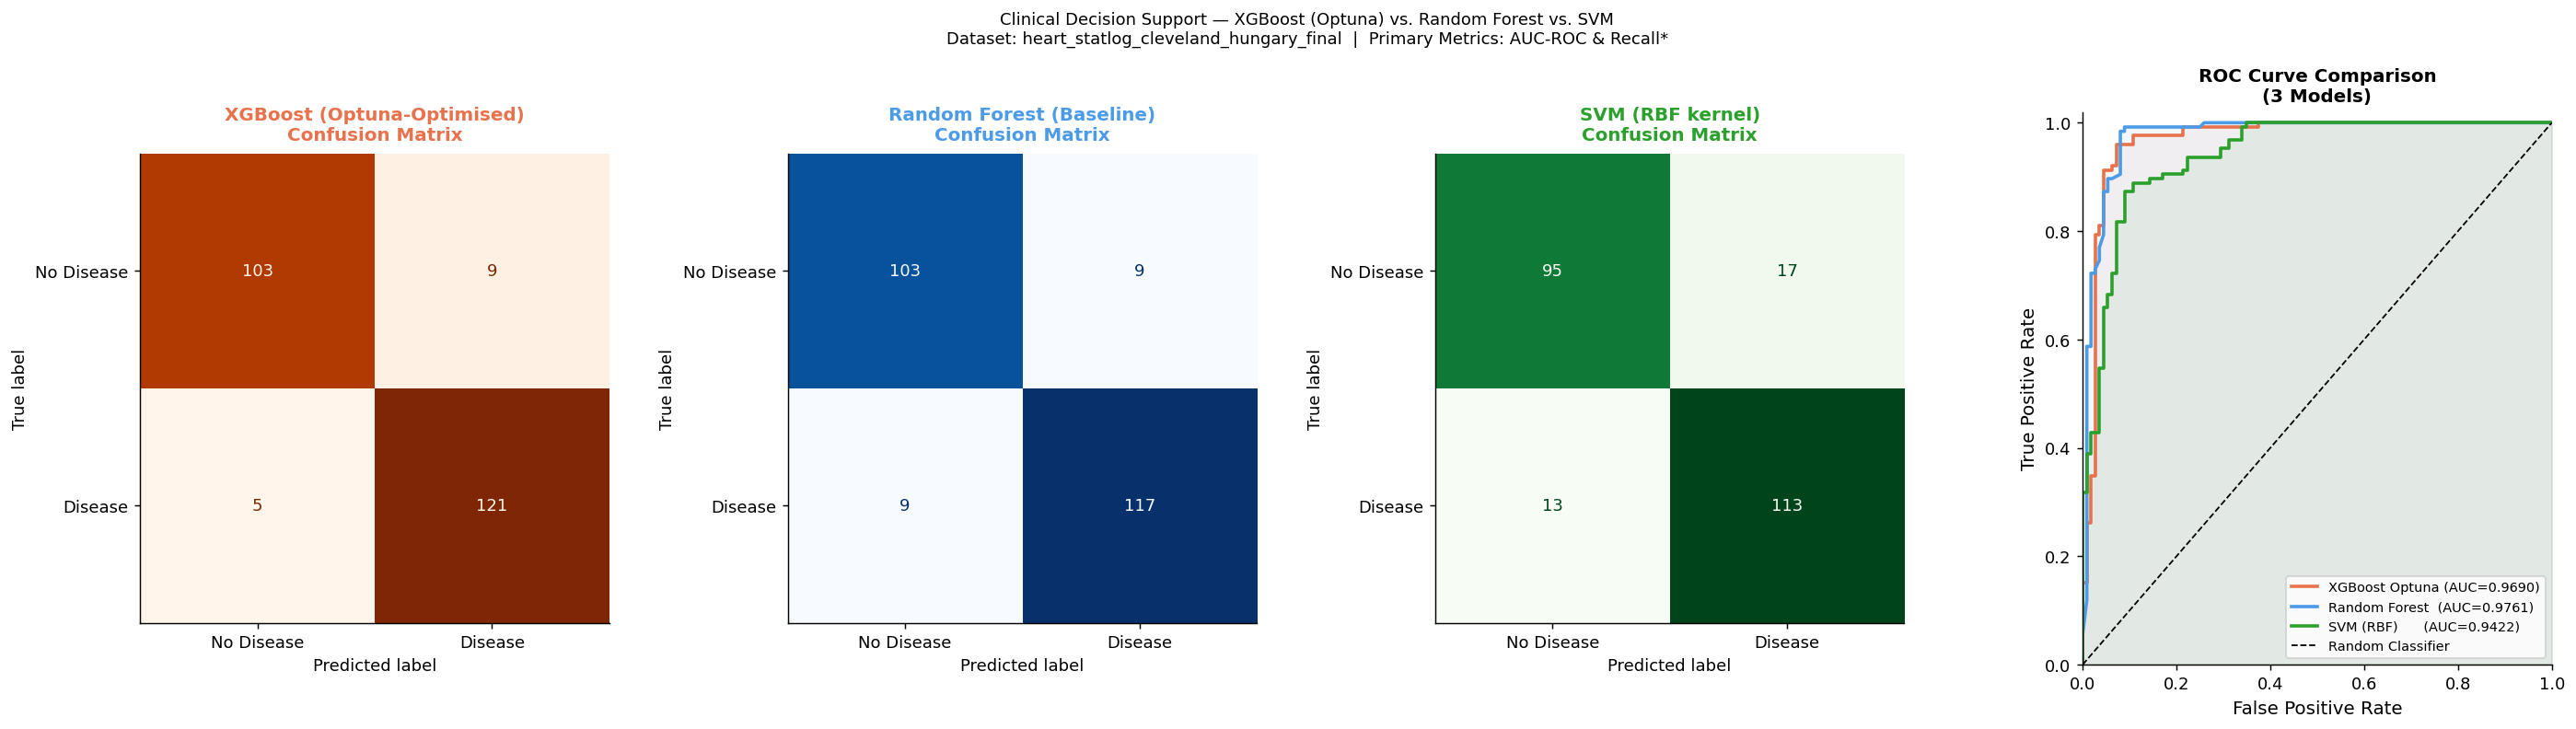

[✓] Saved → confusion_roc_3models.png


In [ ]:
print("[8/8] Generating figures")

# 9a. Confusion matrices + ROC curve (3 panels + 1 ROC)
fig3 = plt.figure(figsize=(26, 6))
gs3  = gridspec.GridSpec(1, 4, figure=fig3, wspace=0.38)

ax_xgb = fig3.add_subplot(gs3[0, 0])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_xgb),
    display_labels=["No Disease", "Disease"]
).plot(ax=ax_xgb, colorbar=False, cmap="Oranges")
ax_xgb.set_title("XGBoost (Optuna-Optimised)\nConfusion Matrix",
                  fontsize=11, fontweight="bold", color=PALETTE["xgb"], pad=8)
ax_xgb.grid(False)

ax_rf = fig3.add_subplot(gs3[0, 1])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rf),
    display_labels=["No Disease", "Disease"]
).plot(ax=ax_rf, colorbar=False, cmap="Blues")
ax_rf.set_title("Random Forest (Baseline)\nConfusion Matrix",
                fontsize=11, fontweight="bold", color=PALETTE["rf"], pad=8)
ax_rf.grid(False)

ax_svm = fig3.add_subplot(gs3[0, 2])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_svm),
    display_labels=["No Disease", "Disease"]
).plot(ax=ax_svm, colorbar=False, cmap="Greens")
ax_svm.set_title("SVM (RBF kernel)\nConfusion Matrix",
                  fontsize=11, fontweight="bold", color=PALETTE["svm"], pad=8)
ax_svm.grid(False)

ax_roc = fig3.add_subplot(gs3[0, 3])
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf,  tpr_rf,  _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

ax_roc.plot(fpr_xgb, tpr_xgb, color=PALETTE["xgb"], lw=2,
            label=f"XGBoost Optuna (AUC={metrics_xgb['AUC-ROC']:.4f})")
ax_roc.plot(fpr_rf,  tpr_rf,  color=PALETTE["rf"],  lw=2,
            label=f"Random Forest  (AUC={metrics_rf['AUC-ROC']:.4f})")
ax_roc.plot(fpr_svm, tpr_svm, color=PALETTE["svm"], lw=2,
            label=f"SVM (RBF)      (AUC={metrics_svm['AUC-ROC']:.4f})")
ax_roc.plot([0, 1], [0, 1], "k--", lw=1, label="Random Classifier")
ax_roc.fill_between(fpr_xgb, tpr_xgb, alpha=0.07, color=PALETTE["xgb"])
ax_roc.fill_between(fpr_rf,  tpr_rf,  alpha=0.07, color=PALETTE["rf"])
ax_roc.fill_between(fpr_svm, tpr_svm, alpha=0.07, color=PALETTE["svm"])
ax_roc.set_xlim([0, 1]); ax_roc.set_ylim([0, 1.02])
ax_roc.set_xlabel("False Positive Rate", fontsize=11)
ax_roc.set_ylabel("True Positive Rate",  fontsize=11)
ax_roc.set_title("ROC Curve Comparison\n(3 Models)", fontsize=11, fontweight="bold")
ax_roc.legend(loc="lower right", fontsize=8)

fig3.suptitle(
    "Clinical Decision Support — XGBoost (Optuna) vs. Random Forest vs. SVM\n"
    "Dataset: heart_statlog_cleveland_hungary_final  |  "
    "Primary Metrics: AUC-ROC & Recall*",
    fontsize=10, y=1.02,
)
plt.savefig("confusion_roc_3models.png", bbox_inches="tight")
plt.show()
print("[✓] Saved → confusion_roc_3models.png")

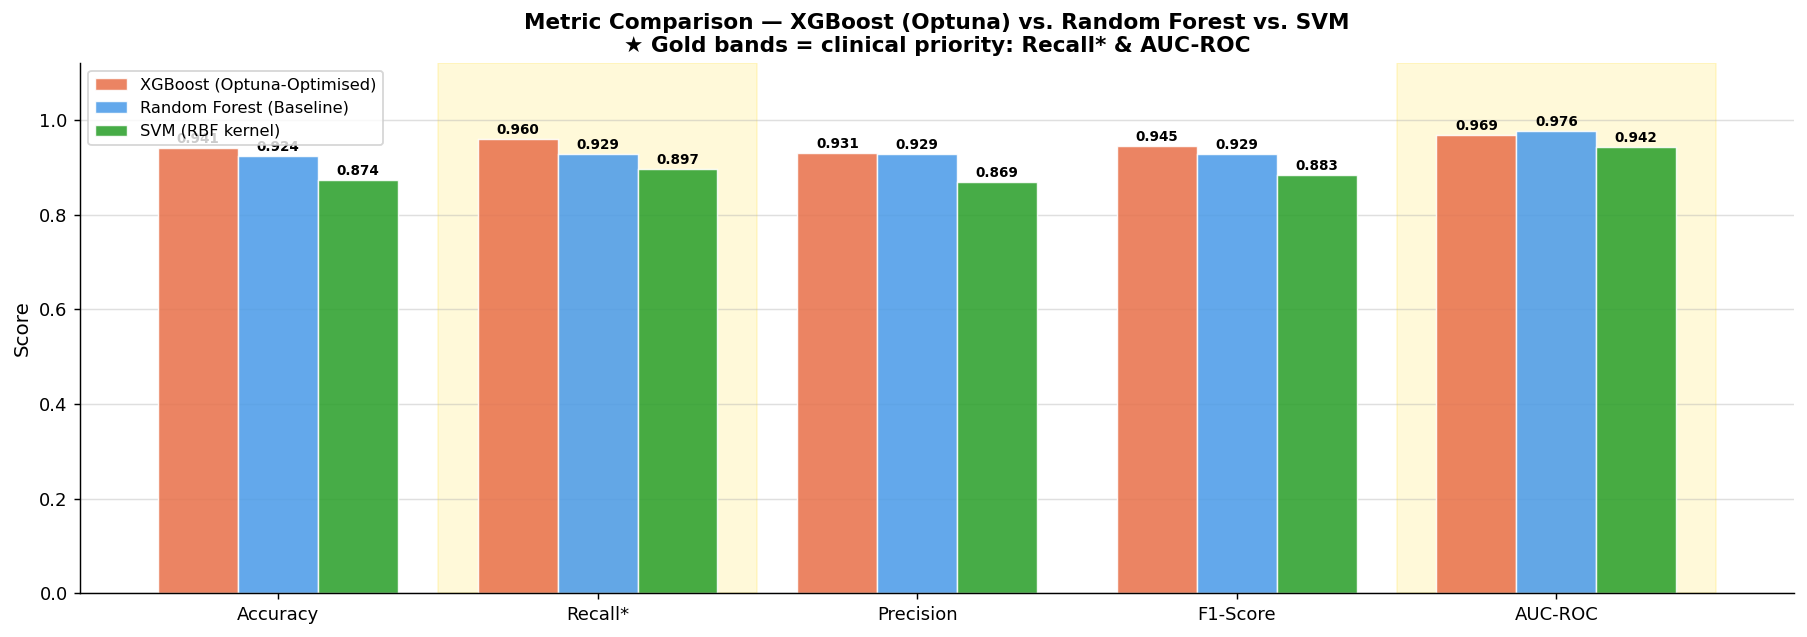

[✓] Saved → metric_comparison_3models.png


In [ ]:
metric_cols = ["Accuracy", "Recall*", "Precision", "F1-Score", "AUC-ROC"]
bar_data    = results_df[metric_cols].T

fig4, ax4 = plt.subplots(figsize=(14, 5))
x, w = np.arange(len(metric_cols)), 0.25

for i, (model_lbl, color) in enumerate(
        zip(bar_data.columns, [PALETTE["xgb"], PALETTE["rf"], PALETTE["svm"]])):
    bars = ax4.bar(x + i*w, bar_data[model_lbl], width=w,
                   label=model_lbl, color=color, alpha=0.87,
                   edgecolor="white", linewidth=0.8)
    for b in bars:
        ax4.text(b.get_x() + b.get_width()/2, b.get_height() + 0.004,
                 f"{b.get_height():.3f}", ha="center", va="bottom",
                 fontsize=7.5, fontweight="bold")

for idx in [metric_cols.index("Recall*"), metric_cols.index("AUC-ROC")]:
    ax4.axvspan(idx - 0.25, idx + 0.25 + 2*w, color="gold", alpha=0.15, zorder=0)

ax4.set_xticks(x + w)
ax4.set_xticklabels(metric_cols, fontsize=10)
ax4.set_ylim(0, 1.12)
ax4.set_ylabel("Score", fontsize=11)
ax4.set_title(
    "Metric Comparison — XGBoost (Optuna) vs. Random Forest vs. SVM\n"
    "★ Gold bands = clinical priority: Recall* & AUC-ROC",
    fontsize=12, fontweight="bold",
)
ax4.legend(fontsize=9)
ax4.yaxis.grid(True, alpha=0.4)
ax4.set_axisbelow(True)
plt.tight_layout()
plt.savefig("metric_comparison_3models.png", bbox_inches="tight")
plt.show()
print("[✓] Saved → metric_comparison_3models.png")

In [ ]:
print("\n" + "=" * 70)
print("  FINAL SUMMARY")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)
print(f"\n  Winner (AUC-ROC) : {winner_name}")
print(f"  Best Optuna CV AUC-ROC : {study.best_value:.4f}")
print("\n  Saved artefacts:")
print("    • confusion_roc_3models.png")
print("    • metric_comparison_3models.png")
print("\n  Key Clinical Insight: Review 'Recall*' — a low recall means the")
print("  model is missing actual heart disease patients (false negatives),")
print("  the most dangerous error type in medical screening.")
print("=" * 70)


  FINAL SUMMARY
                            Accuracy  Recall*  Precision  F1-Score  AUC-ROC
Model                                                                      
XGBoost (Optuna-Optimised)    0.9412   0.9603     0.9308    0.9453   0.9690
Random Forest (Baseline)      0.9244   0.9286     0.9286    0.9286   0.9761
SVM (RBF kernel)              0.8739   0.8968     0.8692    0.8828   0.9422

  Winner (AUC-ROC) : Random Forest (Baseline)
  Best Optuna CV AUC-ROC : 0.9504

  Saved artefacts:
    • confusion_roc_3models.png
    • metric_comparison_3models.png

  Key Clinical Insight: Review 'Recall*' — a low recall means the
  model is missing actual heart disease patients (false negatives),
  the most dangerous error type in medical screening.
